In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.decomposition import PCA

In [3]:
data = pd.read_csv("loan_approval_dataset.csv")
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
data.isna().any()

loan_id                      False
 no_of_dependents            False
 education                   False
 self_employed               False
 income_annum                False
 loan_amount                 False
 loan_term                   False
 cibil_score                 False
 residential_assets_value    False
 commercial_assets_value     False
 luxury_assets_value         False
 bank_asset_value            False
 loan_status                 False
dtype: bool

In [6]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
data[" loan_status"].value_counts(normalize=True)

 Approved    0.62216
 Rejected    0.37784
Name:  loan_status, dtype: float64

Text(0.5, 1.0, 'income annaul title')

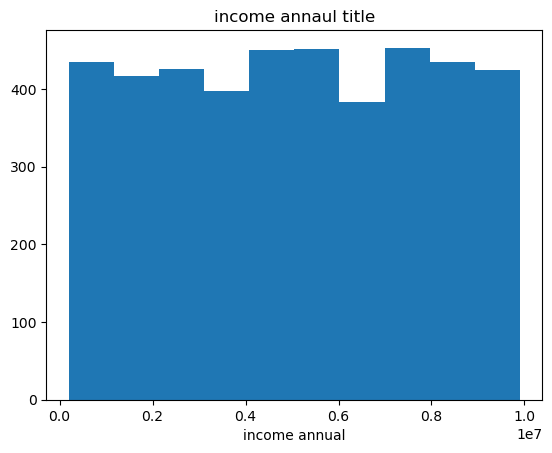

In [8]:
plt.hist(data[" income_annum"])
plt.xlabel("income annual")
plt.title("income annaul title")

Text(0.5, 1.0, 'loan amount title')

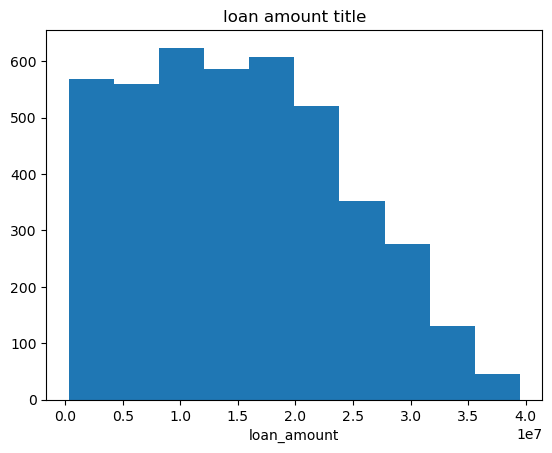

In [9]:
plt.hist(data[" loan_amount"])
plt.xlabel("loan_amount")
plt.title("loan amount title")

<AxesSubplot:>

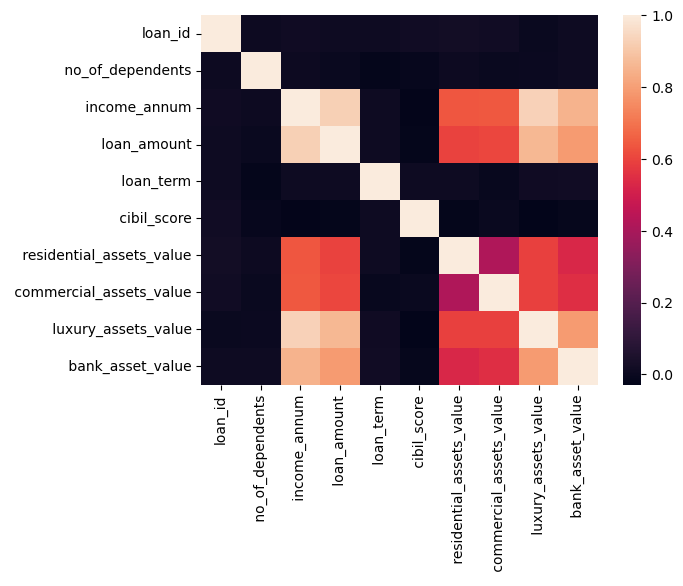

In [10]:
sns.heatmap(data.corr())

might remove loan_amount because it seems to be highly correlated with a lot of the columns. And if loan_amount is high, then that would probably severly affect the outcoem of the y variable.

In [11]:
#splitting the dataset

X = data.drop(columns=[' loan_amount', 'loan_id', " loan_status"], axis = 1)
y = data[" loan_status"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [13]:
#prepare columns transformers for preprocessing 

numerical_columns = X_train.select_dtypes(include = ["int64", "float64"]).columns.to_list()
categorical_columns = X_train.select_dtypes(include = ["object", "category"]).columns.to_list()

numeric_transformer = Pipeline(steps = [('scalar', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Random Forest Classifier 

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
model = RandomForestClassifier(random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

param_grid = {
    'model__n_estimators': [100,200,500],
    'model__max_depth': [2,5,7,9],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(pipeline, param_grid, cv = 5, n_jobs=-1, scoring='roc_auc')

In [16]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scalar',
                                                                                          StandardScaler())]),
                                                                         [' '
                                                                          'no_of_dependents',
                                                                          ' '
                                                                          'income_annum',
                                                                          ' '
                                                                          'loan_term',
                                                                          ' '
                                                   

In [17]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Approved       0.97      0.95      0.96       531
    Rejected       0.93      0.95      0.94       323

    accuracy                           0.95       854
   macro avg       0.95      0.95      0.95       854
weighted avg       0.95      0.95      0.95       854



# XGB Classifier

In [18]:
y_train = y_train.map({' Approved':1, ' Rejected':0})
y_test = y_test.map({ ' Approved':1, ' Rejected':0})

model = xgb.XGBClassifier(random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

param_grid = {
    'model__n_estimators': [100,200,500],
    'model__max_depth': [2,5,7,9]
}

grid = GridSearchCV(pipeline, param_grid, cv = 5, n_jobs=-1, scoring='roc_auc')

In [19]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scalar',
                                                                                          StandardScaler())]),
                                                                         [' '
                                                                          'no_of_dependents',
                                                                          ' '
                                                                          'income_annum',
                                                                          ' '
                                                                          'loan_term',
                                                                          ' '
                                                   

In [20]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       323
           1       0.96      0.97      0.97       531

    accuracy                           0.96       854
   macro avg       0.96      0.96      0.96       854
weighted avg       0.96      0.96      0.96       854



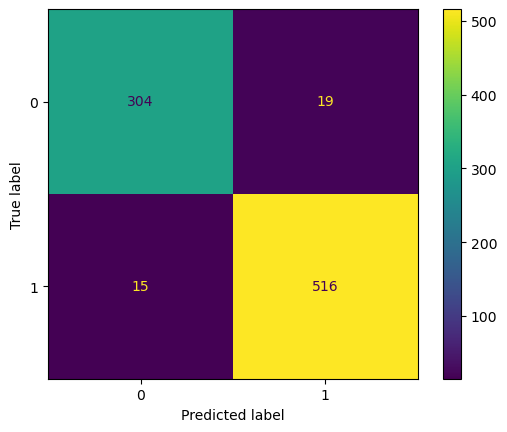

In [22]:
conf_matrix = confusion_matrix(y_test, y_pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = [0, 1])
cm_disp.plot()
plt.show()